### Imports

In [51]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import math

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms, models

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image


### Configuration

In [52]:
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

#########################################################################
########## Decommentez le modele desire, commentez les autres. ##########
# MODEL_NAME = "efficientnet_b2"
# MODEL_NAME = "resnet50"
MODEL_NAME = "custom_cnn"
#########################################################################

DATA_DIR = "../data/processed/"
MODEL_PATH = f"../models/{MODEL_NAME}/{MODEL_NAME}_best.pth"
PREDICTIONS_PATH = f"../models/{MODEL_NAME}/{MODEL_NAME}_predictions.csv"

if MODEL_NAME == "efficientnet_b2":
    IMG_SIZE = 260
    MOD_NAME = "EfficentNet-B2"
elif MODEL_NAME == "resnet50":
    IMG_SIZE = 224
    MOD_NAME = "ResNet-50"
elif MODEL_NAME == "custom_cnn":
    IMG_SIZE = 224
    MOD_NAME = "CNN From Scratch"
    MODEL_PATH = f"../models/{MODEL_NAME}/{MODEL_NAME}_best.pt"

NUM_CLASSES = 4


Device: cpu


### Transformation de la donnee

In [53]:
if MODEL_NAME == "custom_cnn":
    # Pas de normalisation ImageNet : le CNN from scratch a ete entraine
    # uniquement avec Resize + ToTensor (cf. section methodologie du rapport)
    eval_transforms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
    ])
else:
    eval_transforms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])


### Architecture CNN From Scratch\n\nDefinition necessaire uniquement pour reconstruire le modele avant de charger le `state_dict` (contrairement aux modeles torchvision instancies directement dans la cellule \"Modele\").

In [54]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: 224 -> 112
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2: 112 -> 56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 56 -> 28
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 4: 28 -> 14
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 5: 14 -> 7
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


### Modele

In [55]:
if MODEL_NAME == "efficientnet_b2":
    weights = models.EfficientNet_B2_Weights.DEFAULT
    model = models.efficientnet_b2(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

elif MODEL_NAME == "resnet50":
    weights = models.ResNet50_Weights.DEFAULT
    model = models.resnet50(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, NUM_CLASSES)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

elif MODEL_NAME == "custom_cnn":
    model = CustomCNN(num_classes=NUM_CLASSES)
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True)
    # Le checkpoint du CNN from scratch est un dict {'model_state_dict': ..., 'epoch': ..., ...}
    # contrairement aux state_dict bruts de efficientnet_b2 / resnet50
    state_dict = checkpoint["model_state_dict"] if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint else checkpoint
    model.load_state_dict(state_dict)

model = model.to(DEVICE)
model.eval()

print(f"Modele {MODEL_NAME} charge.")


Modele custom_cnn charge.


### Predictions\n\nSi `custom_cnn_predictions.csv` n'existe pas encore, la cellule suivante le genere a partir du jeu de test fige (`data/test`), avec les memes colonnes que le CSV de ResNet-50 (`image_name`, `class`, `prediction`, `probability`, `success`). A ajuster si ton pote a utilise une autre convention de nommage/colonnes pour le sien -- dans ce cas, aligne-toi sur son format exact pour garder les deux CSV comparables.

In [56]:
if not os.path.exists(PREDICTIONS_PATH):
    print(f"{PREDICTIONS_PATH} introuvable, generation des predictions...")

    # ATTENTION : ajuste ce chemin si ton jeu de test fige se trouve ailleurs
    TEST_DIR = "../data/test"

    predict_transforms = eval_transforms  # memes transforms que pour le Grad-CAM
    test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=predict_transforms)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

    idx_to_class = {v: k for k, v in test_dataset.class_to_idx.items()}
    image_paths = [os.path.basename(p) for p, _ in test_dataset.samples]

    rows = []
    offset = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            confs, preds = torch.max(probs, dim=1)

            for i in range(len(labels)):
                true_idx = labels[i].item()
                pred_idx = preds[i].item()
                rows.append({
                    "image_name": image_paths[offset + i],
                    "class": idx_to_class[true_idx],
                    "prediction": idx_to_class[pred_idx],
                    "probability": confs[i].item(),
                    "success": int(true_idx == pred_idx),
                })
            offset += len(labels)

    predictions_df = pd.DataFrame(rows)
    os.makedirs(os.path.dirname(PREDICTIONS_PATH), exist_ok=True)
    predictions_df.to_csv(PREDICTIONS_PATH, index=False)
    print(f"Predictions sauvegardees dans {PREDICTIONS_PATH} ({len(predictions_df)} images)")
else:
    print(f"{PREDICTIONS_PATH} trouve, chargement direct.")


../models/custom_cnn/custom_cnn_predictions.csv trouve, chargement direct.


In [57]:
predictions_df = pd.read_csv(PREDICTIONS_PATH)
predictions_df_error_proba_ascending = predictions_df[predictions_df["success"] == 0].sort_values("probability", ascending=True)
predictions_df_error_proba_descending = predictions_df[predictions_df["success"] == 0].sort_values("probability", ascending=False)
predictions_df_success_class_vp = predictions_df[(predictions_df["success"] == 1) & (predictions_df["class"] == "Viral Pneumonia")].sort_values("probability", ascending=False)
display(predictions_df_error_proba_ascending.head())
display(predictions_df_error_proba_descending.head())
display(predictions_df_success_class_vp.head())


,image_name,class,prediction,probability,success
710,COVID-937.png,COVID,Normal,0.362465,0
1332,Lung_Opacity-3898.png,Lung_Opacity,COVID,0.402799,0
554,COVID-3581.png,COVID,Lung_Opacity,0.447796,0
514,COVID-3422.png,COVID,Lung_Opacity,0.452401,0
413,COVID-2926.png,COVID,Normal,0.468347,0


,image_name,class,prediction,probability,success
1584,Lung_Opacity-4944.png,Lung_Opacity,Normal,0.999895,0
1569,Lung_Opacity-4860.png,Lung_Opacity,COVID,0.999625,0
741,Lung_Opacity-11.png,Lung_Opacity,COVID,0.999539,0
2138,Normal-1761.png,Normal,COVID,0.999521,0
1019,Lung_Opacity-2506.png,Lung_Opacity,Normal,0.999452,0


,image_name,class,prediction,probability,success
3978,Viral Pneumonia-1084.png,Viral Pneumonia,Viral Pneumonia,1.0,1
3984,Viral Pneumonia-110.png,Viral Pneumonia,Viral Pneumonia,1.0,1
4029,Viral Pneumonia-1287.png,Viral Pneumonia,Viral Pneumonia,1.0,1
4023,Viral Pneumonia-127.png,Viral Pneumonia,Viral Pneumonia,1.0,1
4004,Viral Pneumonia-1191.png,Viral Pneumonia,Viral Pneumonia,1.0,1


### Grad-CAM

In [58]:
# Sélection de 3 images depuis le jeu de test gelé, comparables aux cas choisis par ResNet-50
# Cas 1 : prédiction correcte avec forte proba (classe Viral Pneumonia, comme l'original)
cas1 = predictions_df[
    (predictions_df["success"] == 1) & (predictions_df["class"] == "Viral Pneumonia")
].sort_values("probability", ascending=False).iloc[0]["image_name"]

# Cas 2 : prédiction incorrecte avec faible proba (le modèle hésite et se trompe)
cas2 = predictions_df[predictions_df["success"] == 0].sort_values("probability", ascending=True).iloc[0]["image_name"]

# Cas 3 : prédiction incorrecte avec forte proba (le modèle se trompe avec confiance)
cas3 = predictions_df[predictions_df["success"] == 0].sort_values("probability", ascending=False).iloc[0]["image_name"]

images = [cas1, cas2, cas3]
print("Images sélectionnées :", images)

Images sélectionnées : ['Viral Pneumonia-1084.png', 'COVID-937.png', 'Lung_Opacity-4944.png']


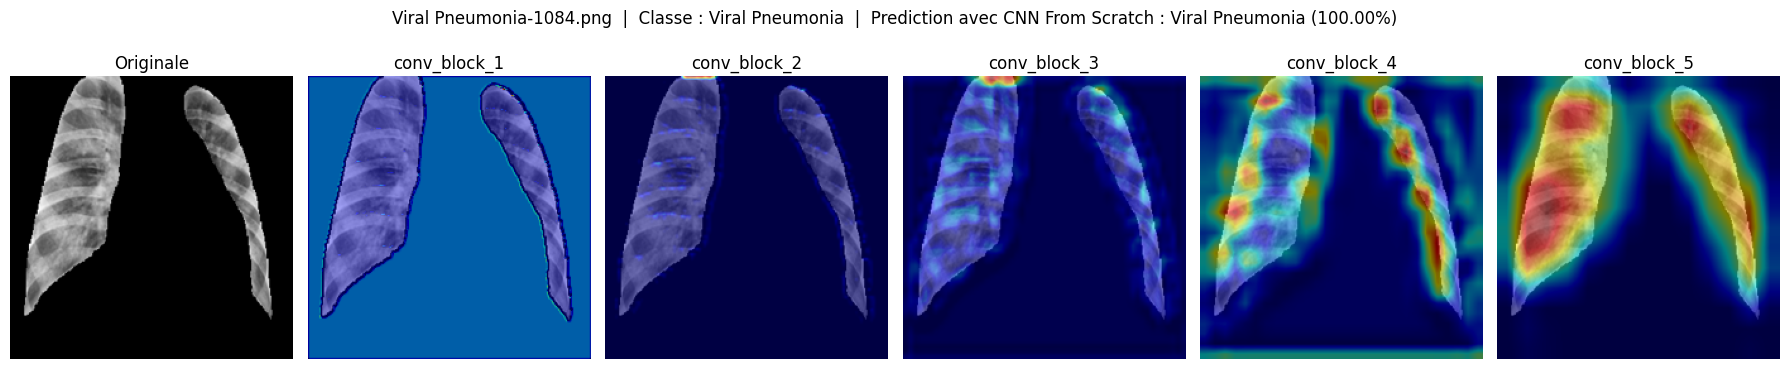

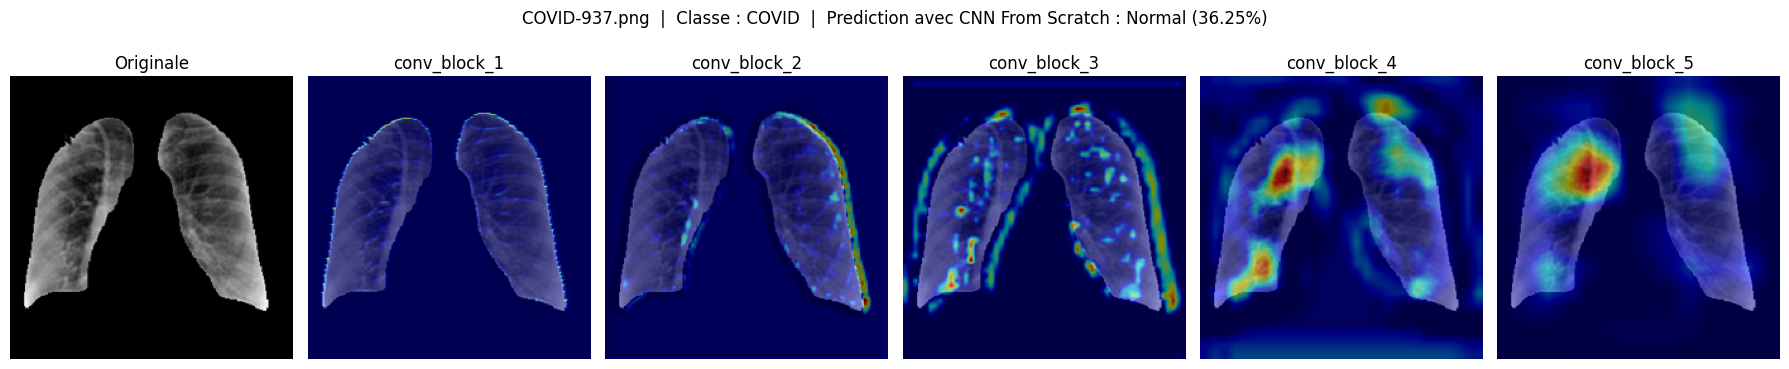

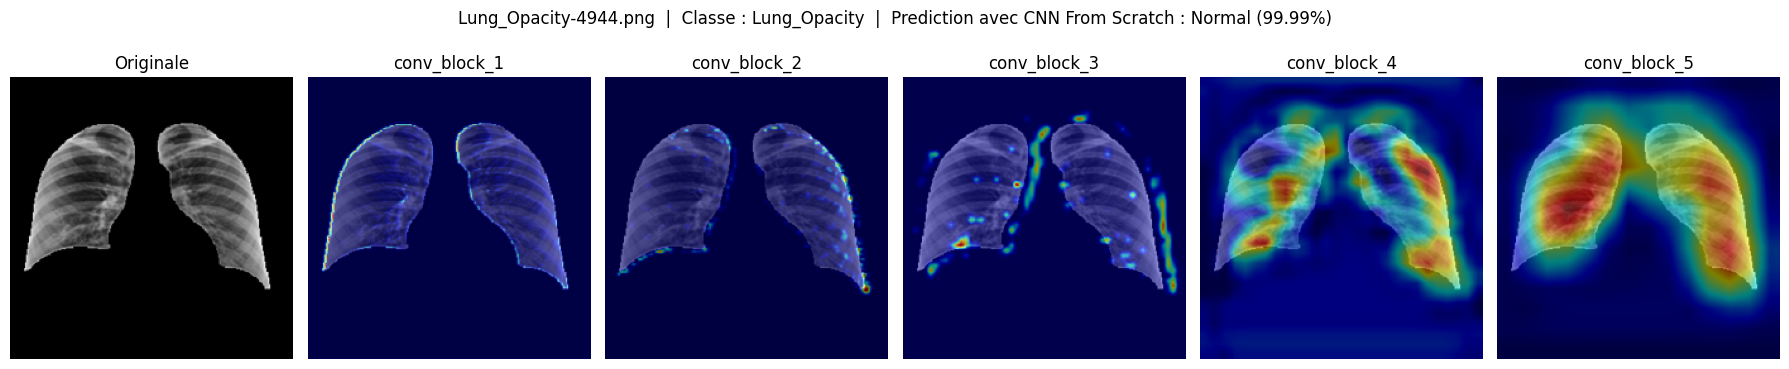

In [59]:
# Image selection
# Cas 1 : prediction correcte avec forte proba
# Cas 2 : prediction incorrecte avec faible proba
# Cas 3 : prediction incorrecte avec forte proba
# Memes images que pour ResNet-50 afin de permettre une comparaison directe entre les deux modeles
for image_name in images:
    image_path = DATA_DIR + f"/{image_name.split('-')[0]}/{image_name}"
    true_class = predictions_df[predictions_df["image_name"] == image_name]["class"].values[0]

    image = Image.open(image_path).convert("L")
    input_tensor = eval_transforms(image).unsqueeze(0).to(DEVICE)
    rgb_img = image.resize((IMG_SIZE, IMG_SIZE))
    rgb_img = np.array(rgb_img).astype(np.float32) / 255.0
    rgb_img = np.stack([rgb_img, rgb_img, rgb_img], axis=-1)

    # Prediction
    pred_class = predictions_df[predictions_df["image_name"] == image_name]["prediction"].values[0]
    pred_prob = predictions_df[predictions_df["image_name"] == image_name]["probability"].values[0]

    # Grad-CAM
    if MODEL_NAME == "efficientnet_b2":
        target_layers_dict = {
        # "features[0]": [model.features[0]],
        # "features[1]": [model.features[1]],
        "features[2]": [model.features[2]],
        # "features[3]": [model.features[3]],
        "features[4]": [model.features[4]],
        # "features[5]": [model.features[5]],
        "features[6]": [model.features[6]],
        # "features[7]": [model.features[7]],
        "features[8]": [model.features[8]],
    }

    elif MODEL_NAME == "resnet50":
        target_layers_dict = {
            "conv_block_1": [model.layer1[-1]],
            "conv_block_2": [model.layer2[-1]],
            "conv_block_3": [model.layer3[-1]],
            "conv_block_4": [model.layer4[-1]],
        }

    elif MODEL_NAME == "custom_cnn":
        target_layers_dict = {
            "conv_block_1": [model.features[5]],   # derniere ReLU du bloc 1
            "conv_block_2": [model.features[12]],  # derniere ReLU du bloc 2
            "conv_block_3": [model.features[19]],  # derniere ReLU du bloc 3
            "conv_block_4": [model.features[26]],  # derniere ReLU du bloc 4
            "conv_block_5": [model.features[30]],  # derniere ReLU du bloc 5 (avant AdaptiveAvgPool)
        }

    visualizations = {}
    for layer_name, target_layers in target_layers_dict.items():
        cam = GradCAM(model=model, target_layers=target_layers)
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        visualizations[layer_name] = visualization

    # Affichage
    n_images = 1 + len(visualizations)
    n_cols = len(target_layers_dict.keys()) + 1
    n_rows = math.ceil(n_images / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows + 1))
    axes = axes.ravel()

    # Image originale
    axes[0].imshow(image.resize((IMG_SIZE, IMG_SIZE)), cmap="gray")
    axes[0].set_title("Originale")
    axes[0].axis("off")

    # Grad-CAM
    for i, (layer_name, visualization) in enumerate(visualizations.items(), start=1):
        axes[i].imshow(visualization)
        axes[i].set_title(layer_name)
        axes[i].axis("off")

    # Desactive les axes inutilises
    for ax in axes[n_images:]:
        ax.axis("off")

    plt.suptitle(f"{image_name}  |  Classe : {true_class}  |  Prediction avec {MOD_NAME} : {pred_class} ({pred_prob:.2%})")

    plt.tight_layout()
    plt.show()
